In [2]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/Users/zhenyu/Library/Python/3.7/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/zhenyu/Library/Python/3.7/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/zhenyu/Library/Python/3.7/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/zhenyu/Library/Python/3.7/lib/python/site-packages/statsmodels/base/model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


                               SARIMAX Results                                
Dep. Variable:                    S_O   No. Observations:                 1076
Model:                ARIMA(40, 1, 5)   Log Likelihood                2213.559
Date:                Wed, 30 Apr 2025   AIC                          -4335.118
Time:                        13:28:19   BIC                          -4106.034
Sample:                             0   HQIC                         -4248.356
                               - 1076                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4936      3.237      0.152      0.879      -5.850       6.838
ar.L2         -0.3491      1.346     -0.259      0.795      -2.988       2.289
ar.L3          0.4364      1.185      0.368      0.7

/Users/zhenyu/Library/Python/3.7/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:843: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  data=self.data,
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi

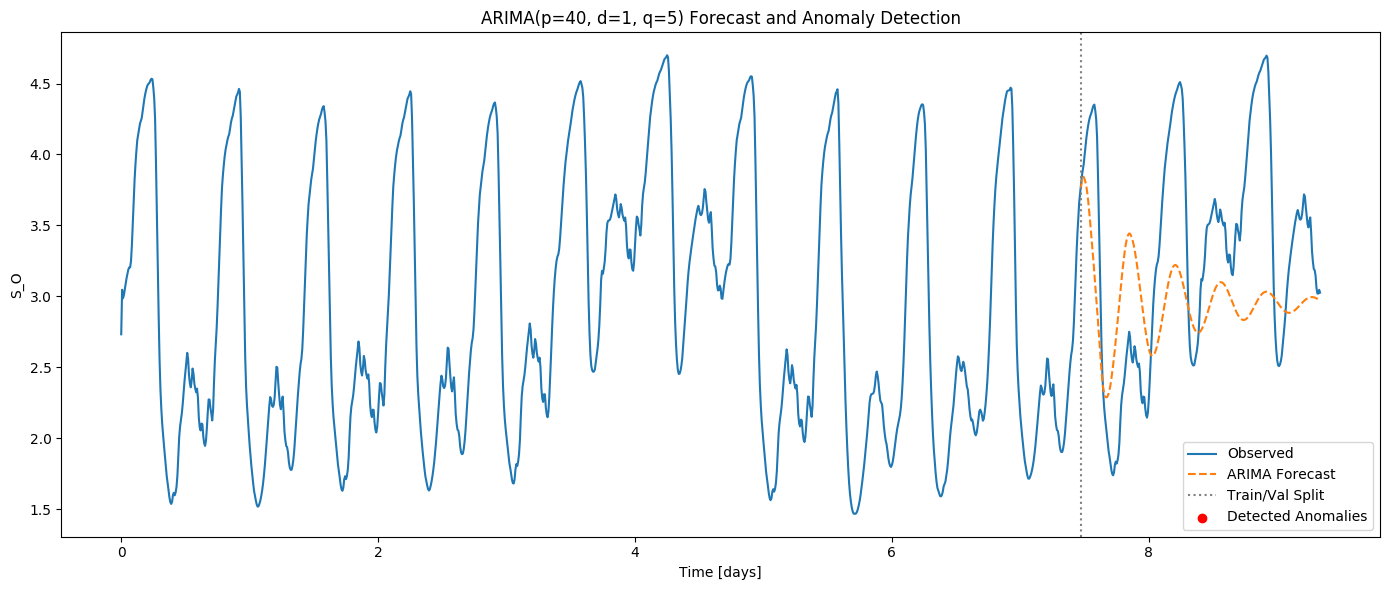

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# --- Load your data ---
df = pd.read_csv("data/bsm1-rainy-r1.csv")
x = df["S_O"].copy()
x.index = np.arange(len(x)) / 144  # Convert to time in days

# --- Split into training (80%) and validation (20%) ---
split_idx = int(len(x) * 0.8)
x_train = x.iloc[:split_idx]
x_val = x.iloc[split_idx:]

# --- Combine for later plotting ---
x_combined = pd.concat([x_train, x_val])

# --- Set ARIMA (p, d, q) manually ---
p = 40  # Autoregressive order
d = 1   # Differencing order
q = 5   # Moving average order

# --- Fit ARIMA model ---
model = ARIMA(x_train, order=(p, d, q))
model_fit = model.fit()
print(model_fit.summary())

# --- Forecast ---
forecast = model_fit.forecast(steps=len(x_val))

# --- Residuals and anomaly detection (optional) ---
residuals = x_val.values - forecast
threshold = 3 * np.std(residuals)
anomalies = np.abs(residuals) > threshold
anomaly_indices = np.where(anomalies)[0] + len(x_train)

# --- Plotting ---
plt.figure(figsize=(14, 6))
plt.plot(x_combined.index, x_combined.values, label="Observed")
plt.plot(x_val.index, forecast, label="ARIMA Forecast", linestyle="--")
plt.scatter(x_combined.index[anomaly_indices], x_combined.iloc[anomaly_indices], color='red', label="Detected Anomalies")

# Mark train/val split
plt.axvline(x=x_combined.index[len(x_train)], color='gray', linestyle=':', label="Train/Val Split")

plt.title(f"ARIMA(p={p}, d={d}, q={q}) Forecast and Anomaly Detection")
plt.xlabel("Time [days]")
plt.ylabel("S_O")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- Load data ---
df = pd.read_csv("data/bsm1-rainy-r1.csv")
x = df["S_O"].copy()
x.index = np.arange(len(x)) / 144  # Convert to time in days

# --- Train/Val Split ---
split_idx = int(len(x) * 0.8)
x_train = x.iloc[:split_idx]
x_val = x.iloc[split_idx:]

# --- Fit SARIMA model manually ---
# (p,d,q) = (1,1,1), seasonal (P,D,Q,m) = (1,1,1,144)
model = SARIMAX(
    x_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 144),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)

# --- Forecast ---
forecast = results.forecast(steps=len(x_val))

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.plot(x.index, x.values, label="Observed", color="blue")
plt.plot(x_val.index, forecast, label="SARIMA Forecast", linestyle="--", color="red")

plt.axvline(x=x_val.index[0], color="gray", linestyle=":", label="Train/Val Split")
plt.title("Manual SARIMA Forecast (Seasonality = 1 day = 144 samples)")
plt.xlabel("Time [days]")
plt.ylabel("S_O")
plt.legend()
plt.tight_layout()
plt.show()


/Users/zhenyu/Library/Python/3.7/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/zhenyu/Library/Python/3.7/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


KeyboardInterrupt: 